In [1]:
import pandas as pd


In [2]:
dataset = pd.read_csv("50_Startups.csv")

In [3]:
dataset


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
dataset = pd.get_dummies(dataset,dtype=int,drop_first=True)

In [5]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [6]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [7]:
independent = dataset [['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]

In [8]:
independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,0,0


In [9]:
dependent = dataset [['Profit']]

In [10]:
dependent

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156991.12
6,156122.51
7,155752.60
8,152211.77
9,149759.96


In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(independent,dependent,test_size=0.30,random_state=0)

In [12]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [13]:
x_train,x_train.shape

(array([[ 1.17644103,  0.84515251,  0.94354978,  2.        , -0.76870611],
        [ 0.96420324,  1.27283565,  0.42738817,  2.        , -0.76870611],
        [-1.47369826,  0.0153175 , -1.52350329, -0.5       ,  1.30088727],
        [-1.48308929, -2.79556363, -1.53809178, -0.5       ,  1.30088727],
        [-0.14952431,  1.13637282, -0.71716495, -0.5       ,  1.30088727],
        [ 0.85312042, -0.04431628,  0.46771725, -0.5       ,  1.30088727],
        [-0.22353674, -0.3151007 , -0.83981652,  2.        , -0.76870611],
        [-0.19454707,  0.21199679, -1.18497259, -0.5       , -0.76870611],
        [ 0.10478723, -0.08388412,  0.48740807, -0.5       , -0.76870611],
        [-1.0096458 , -1.07019473, -0.4040623 , -0.5       , -0.76870611],
        [ 0.06872897, -0.38396487,  0.75036616, -0.5       , -0.76870611],
        [-1.17638797,  0.14067421, -1.26581817, -0.5       ,  1.30088727],
        [ 0.97648631,  0.9689421 ,  0.84958395, -0.5       ,  1.30088727],
        [ 0.39131191,  0.

In [14]:
x_test,x_test.shape

(array([[-0.1403821 ,  2.28593993, -0.63280437,  2.        , -0.76870611],
        [ 0.5692117 , -1.24096039,  0.37552686, -0.5       , -0.76870611],
        [ 0.59465017, -0.51102691,  0.21780907,  2.        , -0.76870611],
        [-0.92249538, -1.51579286, -0.27786722,  2.        , -0.76870611],
        [ 1.65079661, -0.87781077,  1.58762665,  2.        , -0.76870611],
        [-0.01625436,  0.15939469,  1.16810991, -0.5       ,  1.30088727],
        [-1.07956593, -2.24414796, -0.11853428, -0.5       ,  1.30088727],
        [-0.24112469,  1.1235571 , -0.86213689, -0.5       ,  1.30088727],
        [ 0.02242149, -0.03787582,  0.78603258,  2.        , -0.76870611],
        [ 1.41848712, -1.25644297,  1.26760194,  2.        , -0.76870611],
        [-0.3567741 , -0.80359112,  0.10650537,  2.        , -0.76870611],
        [-0.55107837, -1.50272366,  0.03664684, -0.5       ,  1.30088727],
        [ 0.04977002,  0.79103569, -0.5109594 ,  2.        , -0.76870611],
        [-0.54263284,  1.

In [20]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion="poisson",splitter="best",)
regressor=regressor.fit(x_train,y_train)

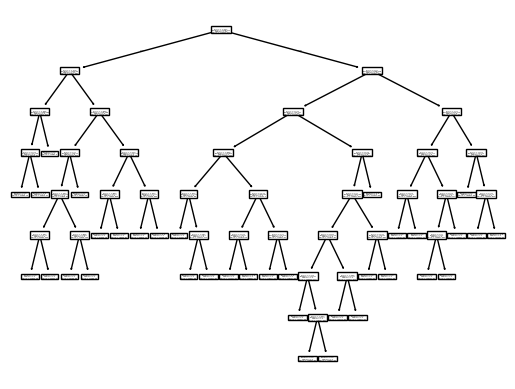

In [21]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()


In [22]:
y_pred=regressor.predict(x_test)

In [23]:
from sklearn.metrics import r2_score
r=r2_score(y_test,y_pred)

In [24]:
r

0.9338868144926072